##### Setup

###### Imports

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda

import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict

from svipy.normflow import inverseAutoRegressiveFlow, maskedAutoRegressiveFlow, normFlowSequential, normFlowPriorNormal
from svipy.vae import vaeEncoder, vaeDecoder, variationalAutoencoder
from svipy.model import reshape, earlyStopping

###### Load data

In [2]:
class imageOnlyDataset(torch.utils.data.Dataset):
    '''
    Class to extract only the images as labels not needed for VAEs.
    '''
    def __init__(self, original, index):
        self.__original = original
        self.__index = index

    @property
    def original(self):
        return self.__original

    @property
    def index(self):
        return self.__index

    def __len__(self):
        return len(self.original)

    def __getitem__(self, index):
        return self.original[index][self.index]

In [3]:
# ToTensor() scales eveything to [0, 1)
thresh = Lambda(lambda x: torch.where(ToTensor()(x) > 0.5, 1.0, 0.0))

# scatter_ to get a one-hot vector
onehot = Lambda(lambda y: torch.zeros(10, dtype=torch.float).scatter_(0, torch.tensor(y), value=1))

trainData = datasets.MNIST(root="../data", train=True, download=True, transform=thresh, target_transform=onehot)
testData = datasets.MNIST(root="../data", train=False, download=True, transform=thresh, target_transform=onehot)

trainImageData = imageOnlyDataset(trainData, 0)  # remove the labels as we dont need them
testImageData = imageOnlyDataset(testData, 0)
print(len(trainData), len(testData), len(trainImageData), len(testImageData))

60000 10000 60000 10000


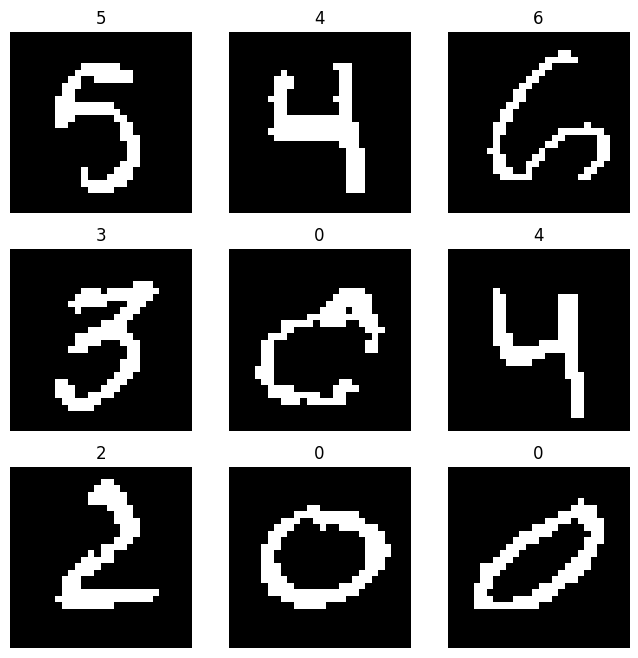

In [4]:
# show some randomly picked numbers
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sidx = torch.randint(len(trainData), size=(1,)).item()
    img, label = trainData[sidx]
    figure.add_subplot(rows, cols, i)
    plt.title(str(torch.argmax(label, dim=0).item()))
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap='gray')
plt.show()

###### Hardware Specs

In [5]:
cudaavailable = torch.cuda.is_available()
mpsavailable = torch.backends.mps.is_available()
curr_device = torch.cuda.current_device()

device = torch.device("cuda" if cudaavailable else "mps" if mpsavailable else "cpu")
device_count = torch.cuda.device_count() 
device_name =  torch.cuda.get_device_name(0)

print(f'Cuda available: {cudaavailable}')
print(f'Current device: {curr_device}')
print(f'Device: {device}')
print(f'Device count: {device_count}')
print(f'Device name: {device_name}')

Cuda available: True
Current device: 0
Device: cuda
Device count: 1
Device name: NVIDIA GeForce GTX 970


In [6]:
def activeUnits(model, dataset, threshold=0.01, batchSize=256, device=device):
    """
    Burda et al.'s "active units" statistic: Var_x[mu(x)] per latent
    dimension, computed across the dataset. A dimension whose posterior
    mean barely moves across different inputs is \"dead\" -- carrying no
    information about x, regardless of what its logVar looks like.
    """
    
    model.eval()
    loader = DataLoader(dataset, batch_size=batchSize, shuffle=False)
    means = []
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            zMean, _ = model.encode(data)
            means.append(zMean.cpu())
    means = torch.cat(means, dim=0)
    
    variance = means.var(dim=0)
    nActive = 0
    for i, v in enumerate(variance):
        active = v.item() > threshold
        nActive += active
        print(f"dim {i}: Var_x[mu] = {v.item():.6f}  ({'active' if active else 'DEAD'})")
    
    print(f"{nActive}/{len(variance)} active units (threshold={threshold})")          
    return variance

##### VAEs with norm flows

In [7]:
class sumBceDecoder(vaeDecoder):
    '''
    VAE decoder with cross entropy loss (canonical decoder uses MSE)
    '''
    @staticmethod
    def reconstructionLoss(x: torch.Tensor, recon: torch.Tensor) -> torch.Tensor:
        bce = torch.nn.functional.binary_cross_entropy(recon, x, reduction='none')
        return torch.mean(torch.sum(torch.flatten(bce, start_dim=1), dim=1))

###### Masked autoregressive flows

In [8]:
in_dims = 28 * 28
hid_dims = 16

encoder = nn.Sequential(nn.Flatten(),
                        nn.Linear(in_dims, 64),
                        nn.ReLU(),
                        nn.Linear(64, 64),
                        nn.ReLU(),
                        nn.Linear(64, 2 * hid_dims))
encoder = vaeEncoder(encoder)

decoder = nn.Sequential(nn.Linear(hid_dims, 64),
                        nn.ReLU(),
                        nn.Linear(64, 64),
                        nn.ReLU(),
                        nn.Linear(64, in_dims),
                        reshape([1, 28, 28]),
                        nn.Sigmoid())
decoder = sumBceDecoder(decoder)

prior = normFlowPriorNormal(normFlowSequential(OrderedDict([('maf1', maskedAutoRegressiveFlow([16, 256, 256])),
                                                            ('maf2', maskedAutoRegressiveFlow([16, 256, 256])),
                                                            ('maf3', maskedAutoRegressiveFlow([16, 256, 256]))
                                                           ])), 28 * 28)

model_vae_maf = variationalAutoencoder(encoder, decoder, prior=prior).to(device)

In [9]:
learning_rate = 0.001
batch_size = 128
epochs = 50

trainLoader = DataLoader(trainImageData, batch_size=batch_size, shuffle=True)
validLoader = DataLoader(testImageData, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(model_vae_maf.parameters(), lr=learning_rate)
stopper = earlyStopping(patience=3, minDelta=0.1, mode='min', restoreBestWeights=True)

In [10]:
model_vae_maf.trainLoop(trainLoader, optimizer, epochs, 
                        reportIters=100, scheduler=None,
                        checkpointPath='../checkpoints/mnist_vae/',
                        checkPointName='vae_norm_maf',
                        validDataLoader=validLoader,
                        earlyStopper=stopper)

Epoch 1
-------------------------------
totalLoss: 908.887634 reconLoss: 201.519653 klLoss: 707.367981[12800/60000]
totalLoss: 895.744995 reconLoss: 188.032867 klLoss: 707.712158[25600/60000]
totalLoss: 890.116943 reconLoss: 180.951752 klLoss: 709.165222[38400/60000]
totalLoss: 887.814392 reconLoss: 178.132751 klLoss: 709.681641[51200/60000]
Validation Error: 880.359327
Epoch 2
-------------------------------
totalLoss: 869.607422 reconLoss: 158.261398 klLoss: 711.346008[12800/60000]
totalLoss: 862.323059 reconLoss: 149.775558 klLoss: 712.547485[25600/60000]
totalLoss: 856.756836 reconLoss: 142.939240 klLoss: 713.817566[38400/60000]
totalLoss: 861.028564 reconLoss: 145.758636 klLoss: 715.269897[51200/60000]
Validation Error: 847.671782
Epoch 3
-------------------------------
totalLoss: 843.662292 reconLoss: 127.527786 klLoss: 716.134521[12800/60000]
totalLoss: 839.558167 reconLoss: 123.186600 klLoss: 716.371582[25600/60000]
totalLoss: 829.076843 reconLoss: 112.352951 klLoss: 716.723877

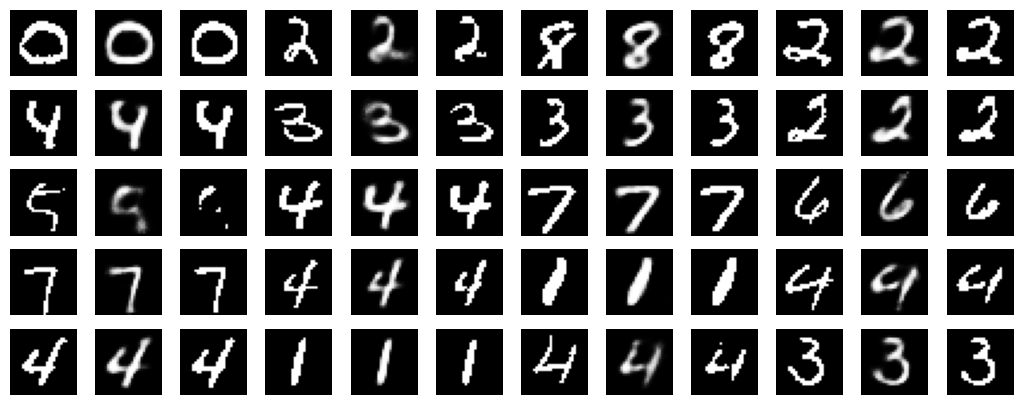

In [11]:
nCols = 12
nRows = 5

figure = plt.figure(figsize=(13, 5))
model_vae_maf.eval()

with torch.no_grad():
    for i in range(4 * nRows):
        sidx = torch.randint(len(trainData), size=(1,)).item()
        img, label = trainData[sidx]
        figure.add_subplot(nRows, nCols, 3 * i + 1)
        plt.axis("off")
        plt.imshow(img.squeeze(), cmap='gray')
        
        img = model_vae_maf.decode(model_vae_maf.encode(trainImageData[sidx].unsqueeze(0).to(device))[0])
        img = img.cpu().detach()
        figure.add_subplot(nRows, nCols, 3 * i + 2)
        plt.axis("off")
        plt.imshow(img.numpy().squeeze(), cmap='gray')

        figure.add_subplot(nRows, nCols, 3 * i + 3)
        plt.axis("off")
        plt.imshow(torch.where(img > 0.5, 1.0, 0.0).numpy().squeeze(), cmap='gray')

plt.show()

In [12]:
activeUnits(model_vae_maf, trainImageData)

dim 0: Var_x[mu] = 16.785608  (active)
dim 1: Var_x[mu] = 8.434588  (active)
dim 2: Var_x[mu] = 10.505187  (active)
dim 3: Var_x[mu] = 20.040192  (active)
dim 4: Var_x[mu] = 16.546047  (active)
dim 5: Var_x[mu] = 23.072771  (active)
dim 6: Var_x[mu] = 13.388389  (active)
dim 7: Var_x[mu] = 17.358955  (active)
dim 8: Var_x[mu] = 13.953300  (active)
dim 9: Var_x[mu] = 32.049515  (active)
dim 10: Var_x[mu] = 17.455898  (active)
dim 11: Var_x[mu] = 18.864902  (active)
dim 12: Var_x[mu] = 17.008011  (active)
dim 13: Var_x[mu] = 19.850470  (active)
dim 14: Var_x[mu] = 11.182851  (active)
dim 15: Var_x[mu] = 31.990139  (active)
16/16 active units (threshold=0.01)


tensor([16.7856,  8.4346, 10.5052, 20.0402, 16.5460, 23.0728, 13.3884, 17.3590,
        13.9533, 32.0495, 17.4559, 18.8649, 17.0080, 19.8505, 11.1829, 31.9901])

###### Inverse Autoregressive Flows

In [13]:
in_dims = 28 * 28
hid_dims = 16

encoder = nn.Sequential(nn.Flatten(),
                        nn.Linear(in_dims, 64),
                        nn.ReLU(),
                        nn.Linear(64, 64),
                        nn.ReLU(),
                        nn.Linear(64, 2 * hid_dims))
encoder = vaeEncoder(encoder)

decoder = nn.Sequential(nn.Linear(hid_dims, 64),
                        nn.ReLU(),
                        nn.Linear(64, 64),
                        nn.ReLU(),
                        nn.Linear(64, in_dims),
                        reshape([1, 28, 28]),
                        nn.Sigmoid())
decoder = sumBceDecoder(decoder)


prior = normFlowPriorNormal(normFlowSequential(OrderedDict([('iaf1', inverseAutoRegressiveFlow([16, 16, 16])),
                                                            ('iaf2', inverseAutoRegressiveFlow([16, 16, 16])),
                                                            # ('iaf3', inverseAutoRegressiveFlow([16, 256, 256]))
                                                           ])), 28 * 28)

model_vae_iaf = variationalAutoencoder(encoder, decoder, prior=prior).to(device)

In [14]:
learning_rate = 0.001
batch_size = 128
epochs = 50

trainLoader = DataLoader(trainImageData, batch_size=batch_size, shuffle=True)
validLoader = DataLoader(testImageData, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(model_vae_iaf.parameters(), lr=learning_rate)
stopper = earlyStopping(patience=3, minDelta=0.1, mode='min', restoreBestWeights=True)

In [15]:
model_vae_iaf.trainLoop(trainLoader, optimizer, epochs, 
                        reportIters=100, scheduler=None,
                        checkpointPath='../checkpoints/mnist_vae/',
                        checkPointName='vae_norm_iaf',
                        validDataLoader=validLoader,
                        earlyStopper=stopper)

Epoch 1
-------------------------------
totalLoss: 909.684998 reconLoss: 202.004944 klLoss: 707.680054[12800/60000]
totalLoss: 898.403137 reconLoss: 190.561340 klLoss: 707.841797[25600/60000]
totalLoss: 896.528687 reconLoss: 187.920807 klLoss: 708.607910[38400/60000]
totalLoss: 886.243225 reconLoss: 174.812195 klLoss: 711.431030[51200/60000]
Validation Error: 877.225365
Epoch 2
-------------------------------
totalLoss: 871.413635 reconLoss: 158.490158 klLoss: 712.923462[12800/60000]
totalLoss: 869.165283 reconLoss: 155.568802 klLoss: 713.596497[25600/60000]
totalLoss: 864.219482 reconLoss: 149.541595 klLoss: 714.677917[38400/60000]
totalLoss: 860.304321 reconLoss: 145.280029 klLoss: 715.024292[51200/60000]
Validation Error: 848.630237
Epoch 3
-------------------------------
totalLoss: 848.518188 reconLoss: 132.191849 klLoss: 716.326355[12800/60000]
totalLoss: 839.159607 reconLoss: 122.406921 klLoss: 716.752686[25600/60000]
totalLoss: 838.752625 reconLoss: 121.709274 klLoss: 717.043335

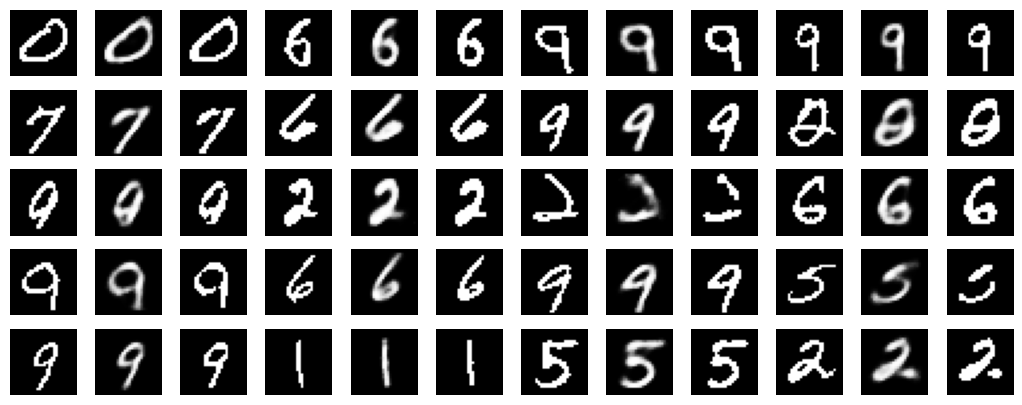

In [16]:
nCols = 12
nRows = 5

figure = plt.figure(figsize=(13, 5))
model_vae_iaf.eval()

with torch.no_grad():
    for i in range(4 * nRows):
        sidx = torch.randint(len(trainData), size=(1,)).item()
        img, label = trainData[sidx]
        figure.add_subplot(nRows, nCols, 3 * i + 1)
        plt.axis("off")
        plt.imshow(img.squeeze(), cmap='gray')
        
        img = model_vae_iaf.decode(model_vae_iaf.encode(trainImageData[sidx].unsqueeze(0).to(device))[0])
        img = img.cpu().detach()
        figure.add_subplot(nRows, nCols, 3 * i + 2)
        plt.axis("off")
        plt.imshow(img.numpy().squeeze(), cmap='gray')

        figure.add_subplot(nRows, nCols, 3 * i + 3)
        plt.axis("off")
        plt.imshow(torch.where(img > 0.5, 1.0, 0.0).numpy().squeeze(), cmap='gray')

plt.show()

In [17]:
activeUnits(model_vae_iaf, trainImageData)

dim 0: Var_x[mu] = 8.063934  (active)
dim 1: Var_x[mu] = 24.423401  (active)
dim 2: Var_x[mu] = 1.618959  (active)
dim 3: Var_x[mu] = 11.484173  (active)
dim 4: Var_x[mu] = 13.489661  (active)
dim 5: Var_x[mu] = 5.869965  (active)
dim 6: Var_x[mu] = 9.201074  (active)
dim 7: Var_x[mu] = 11.052580  (active)
dim 8: Var_x[mu] = 63.487846  (active)
dim 9: Var_x[mu] = 32.905525  (active)
dim 10: Var_x[mu] = 11.461534  (active)
dim 11: Var_x[mu] = 4.091205  (active)
dim 12: Var_x[mu] = 24.878613  (active)
dim 13: Var_x[mu] = 0.419021  (active)
dim 14: Var_x[mu] = 2.456319  (active)
dim 15: Var_x[mu] = 33.160194  (active)
16/16 active units (threshold=0.01)


tensor([ 8.0639, 24.4234,  1.6190, 11.4842, 13.4897,  5.8700,  9.2011, 11.0526,
        63.4878, 32.9055, 11.4615,  4.0912, 24.8786,  0.4190,  2.4563, 33.1602])